In [ ]:
import os
for dirname, _, filenames in os.walk('/home/documents/MLBA'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/food_wastage_data.csv


# LIBRARIES

In [1]:
!pip install shap

In [2]:
!pip install xgboost===2.0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 5.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.0.3
    Uninstalling xgboost-2.0.3:
      Successfully uninstalled xgboost-2.0.3


In [3]:
import xgboost as xgb
xgb.__version__

'2.0.2'

In [4]:
# Re-importing necessary libraries after reset
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import shap
import seaborn as sns
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

2024-03-30 13:47:25.106665: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-30 13:47:25.106930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-30 13:47:25.255450: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
!python --version

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


Python 3.10.13


In [10]:
pd.__version__

'2.2.1'

# EDA

In [ ]:
data = pd.read_csv('food_wastage_data.csv')

In [13]:
data.rename(columns=lambda x: x.replace(' ', '_').lower(), inplace=True)

In [14]:
data.head()

,type_of_food,number_of_guests,event_type,quantity_of_food,storage_conditions,purchase_history,seasonality,preparation_method,geographical_location,pricing,wastage_food_amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25


In [15]:
data.shape

(1782, 11)

In [16]:
data.columns

Index(['type_of_food', 'number_of_guests', 'event_type', 'quantity_of_food',
       'storage_conditions', 'purchase_history', 'seasonality',
       'preparation_method', 'geographical_location', 'pricing',
       'wastage_food_amount'],
      dtype='object')

In [17]:
data.head(1)

,type_of_food,number_of_guests,event_type,quantity_of_food,storage_conditions,purchase_history,seasonality,preparation_method,geographical_location,pricing,wastage_food_amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25


In [18]:
# one hot encoding
columns_to_encode = ['type_of_food', 'event_type', 'storage_conditions', 'purchase_history', 'seasonality', 'preparation_method', 'geographical_location', 'pricing']

df_enc = pd.get_dummies(data, columns = columns_to_encode)
df_enc.rename(columns=lambda x: x.replace(' ', '_').lower(), inplace=True)

In [19]:
df_enc.head(5)

,number_of_guests,quantity_of_food,wastage_food_amount,type_of_food_baked_goods,type_of_food_dairy_products,type_of_food_fruits,type_of_food_meat,type_of_food_vegetables,event_type_birthday,event_type_corporate,...,seasonality_winter,preparation_method_buffet,preparation_method_finger_food,preparation_method_sit-down_dinner,geographical_location_rural,geographical_location_suburban,geographical_location_urban,pricing_high,pricing_low,pricing_moderate
0,310,450,25,False,False,False,True,False,False,True,...,False,True,False,False,False,False,True,False,True,False
1,400,500,40,False,False,False,True,False,True,False,...,True,True,False,False,False,True,False,True,False,False
2,302,371,27,False,False,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
3,491,497,32,False,False,False,True,False,True,False,...,False,False,True,False,True,False,False,True,False,False
4,300,400,25,False,False,False,True,False,False,True,...,True,False,True,False,False,False,True,False,False,True


In [20]:
df_enc.shape

(1782, 28)

In [21]:
df_enc.dtypes

number_of_guests                       int64
quantity_of_food                       int64
wastage_food_amount                    int64
type_of_food_baked_goods                bool
type_of_food_dairy_products             bool
type_of_food_fruits                     bool
type_of_food_meat                       bool
type_of_food_vegetables                 bool
event_type_birthday                     bool
event_type_corporate                    bool
event_type_social_gathering             bool
event_type_wedding                      bool
storage_conditions_refrigerated         bool
storage_conditions_room_temperature     bool
purchase_history_occasional             bool
purchase_history_regular                bool
seasonality_all_seasons                 bool
seasonality_summer                      bool
seasonality_winter                      bool
preparation_method_buffet               bool
preparation_method_finger_food          bool
preparation_method_sit-down_dinner      bool
geographic

In [22]:
df_enc = df_enc.astype({col: int for col in df_enc.select_dtypes(include='bool').columns})

<Axes: >

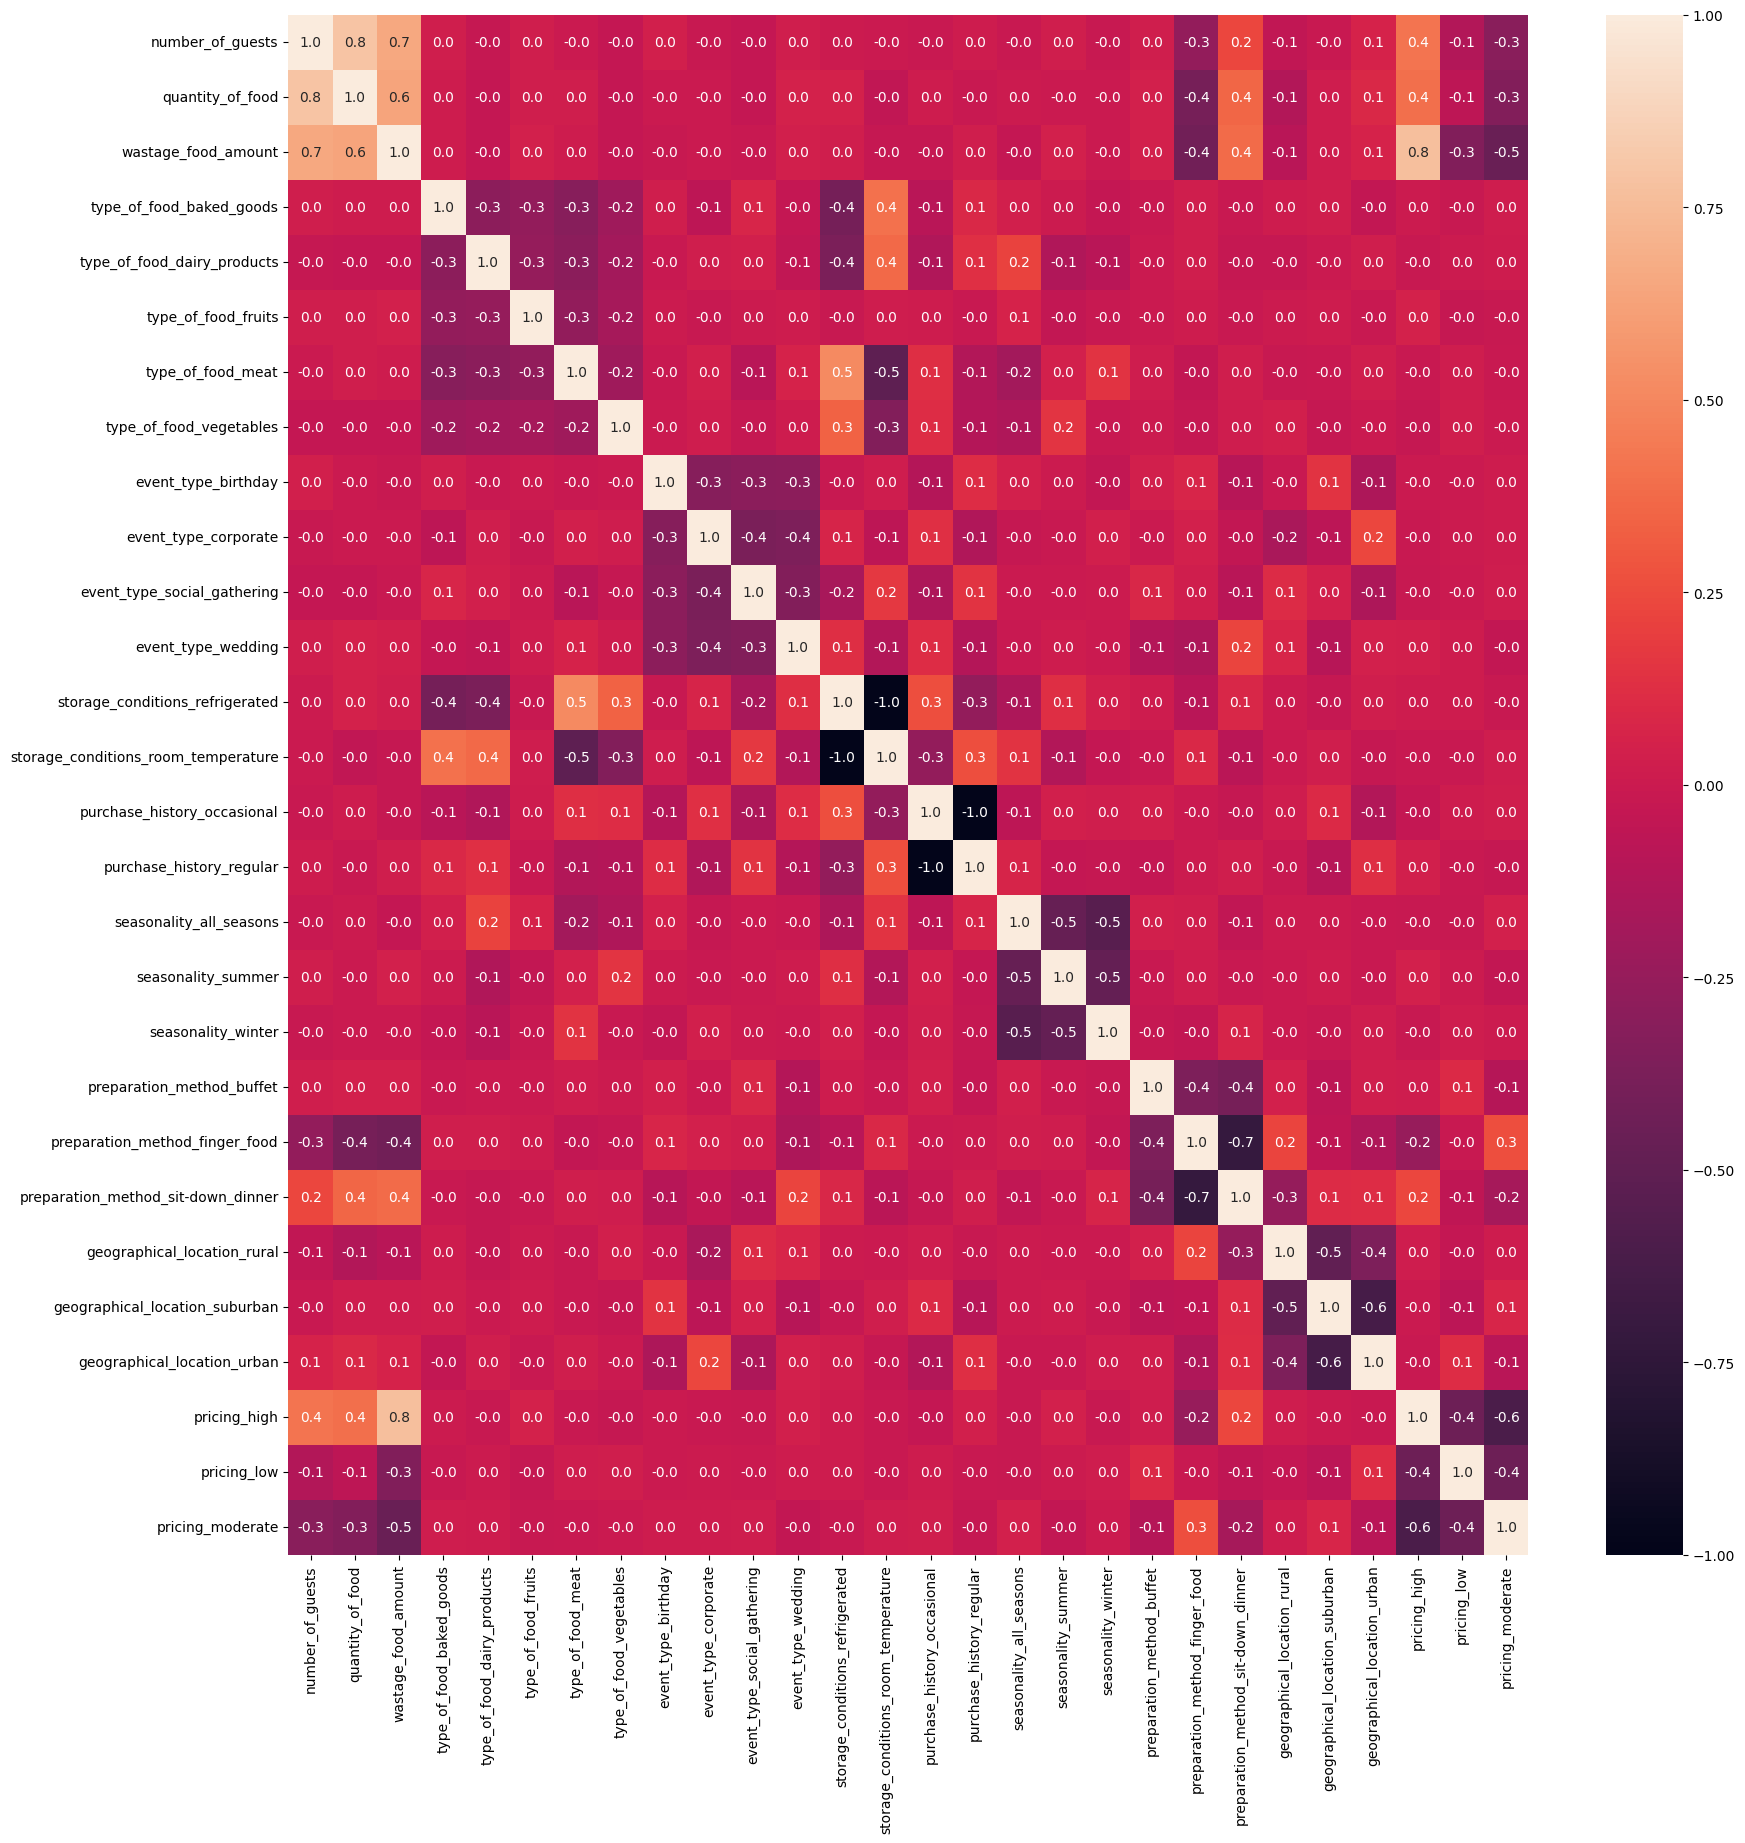

In [23]:
plt.figure(figsize=(20, 20))  # Adjust the width and height as needed
sns.heatmap(df_enc.corr(), annot=True, fmt='.1f')

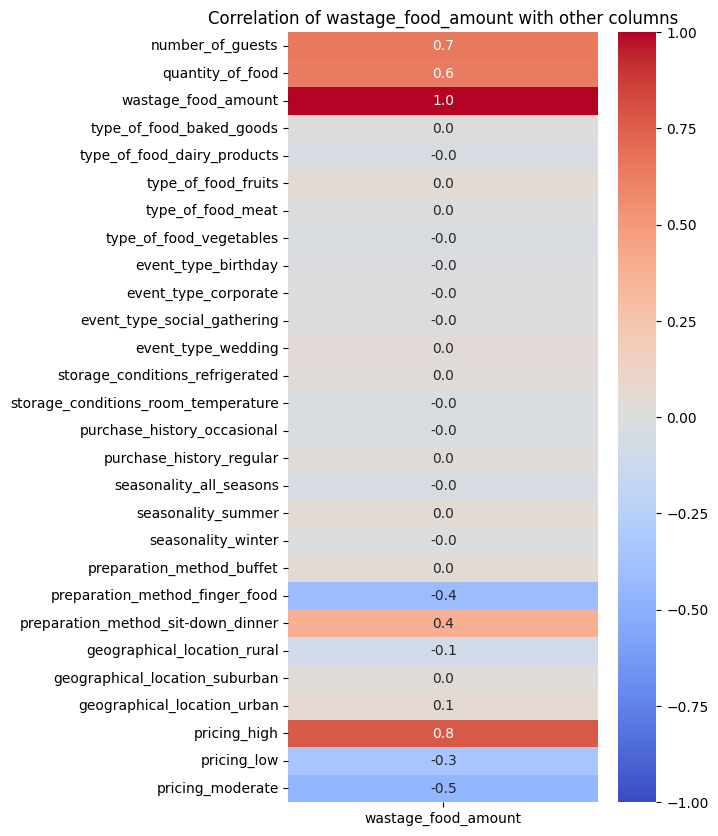

In [24]:
# Select the column for the heatmap
column_for_heatmap = 'wastage_food_amount'

# Compute the correlation of the selected column with all other columns
correlation = df_enc.corr()[[column_for_heatmap]]

# Plot heatmap
plt.figure(figsize=(5, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.1f')

plt.title(f'Correlation of {column_for_heatmap} with other columns')
plt.show()

In [25]:
df_enc['pricing_low'].value_counts()

pricing_low
0    1347
1     435
Name: count, dtype: int64

In [26]:
df_enc[df_enc['pricing_moderate']==0]['wastage_food_amount'].describe()

count    1109.000000
mean       32.289450
std        11.054676
min        10.000000
25%        24.000000
50%        35.000000
75%        40.000000
max        63.000000
Name: wastage_food_amount, dtype: float64

In [27]:
df_enc[df_enc['pricing_moderate']==1]['wastage_food_amount'].describe()

count    673.000000
mean      22.352155
std        5.196659
min       15.000000
25%       20.000000
50%       22.000000
75%       25.000000
max       35.000000
Name: wastage_food_amount, dtype: float64

In [28]:
df_enc.columns

Index(['number_of_guests', 'quantity_of_food', 'wastage_food_amount',
       'type_of_food_baked_goods', 'type_of_food_dairy_products',
       'type_of_food_fruits', 'type_of_food_meat', 'type_of_food_vegetables',
       'event_type_birthday', 'event_type_corporate',
       'event_type_social_gathering', 'event_type_wedding',
       'storage_conditions_refrigerated',
       'storage_conditions_room_temperature', 'purchase_history_occasional',
       'purchase_history_regular', 'seasonality_all_seasons',
       'seasonality_summer', 'seasonality_winter', 'preparation_method_buffet',
       'preparation_method_finger_food', 'preparation_method_sit-down_dinner',
       'geographical_location_rural', 'geographical_location_suburban',
       'geographical_location_urban', 'pricing_high', 'pricing_low',
       'pricing_moderate'],
      dtype='object')

In [29]:
required_columns = ['number_of_guests', 'quantity_of_food', 'wastage_food_amount',
       'type_of_food_baked_goods', 'type_of_food_dairy_products',
       'type_of_food_fruits', 'type_of_food_meat', 'type_of_food_vegetables',
#        'event_type_birthday', 'event_type_corporate',
#        'event_type_social_gathering', 'event_type_wedding',
       'storage_conditions_refrigerated','storage_conditions_room_temperature', 'seasonality_all_seasons',
       'seasonality_summer', 'seasonality_winter', 'preparation_method_buffet',
       'preparation_method_finger_food', 'preparation_method_sit-down_dinner',
       'geographical_location_rural', 'geographical_location_suburban',
       'geographical_location_urban', 'pricing_high', 'pricing_low',
       'pricing_moderate']

# MODELING

## SUPERVISED

In [30]:
df_enc_copy = df_enc[required_columns].copy(deep = True)

In [31]:
df_enc_copy.head()

,number_of_guests,quantity_of_food,wastage_food_amount,type_of_food_baked_goods,type_of_food_dairy_products,type_of_food_fruits,type_of_food_meat,type_of_food_vegetables,storage_conditions_refrigerated,storage_conditions_room_temperature,...,seasonality_winter,preparation_method_buffet,preparation_method_finger_food,preparation_method_sit-down_dinner,geographical_location_rural,geographical_location_suburban,geographical_location_urban,pricing_high,pricing_low,pricing_moderate
0,310,450,25,0,0,0,1,0,1,0,...,0,1,0,0,0,0,1,0,1,0
1,400,500,40,0,0,0,1,0,0,1,...,1,1,0,0,0,1,0,1,0,0
2,302,371,27,0,0,0,0,1,1,0,...,0,1,0,0,0,1,0,0,1,0
3,491,497,32,0,0,0,1,0,1,0,...,0,0,1,0,1,0,0,1,0,0
4,300,400,25,0,0,0,1,0,1,0,...,1,0,1,0,0,0,1,0,0,1


In [32]:
y = df_enc_copy['wastage_food_amount']
df_enc_copy.drop(columns = ['wastage_food_amount'], inplace = True)
X = df_enc_copy

In [33]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
X.dtypes

number_of_guests                       int64
quantity_of_food                       int64
type_of_food_baked_goods               int64
type_of_food_dairy_products            int64
type_of_food_fruits                    int64
type_of_food_meat                      int64
type_of_food_vegetables                int64
storage_conditions_refrigerated        int64
storage_conditions_room_temperature    int64
seasonality_all_seasons                int64
seasonality_summer                     int64
seasonality_winter                     int64
preparation_method_buffet              int64
preparation_method_finger_food         int64
preparation_method_sit-down_dinner     int64
geographical_location_rural            int64
geographical_location_suburban         int64
geographical_location_urban            int64
pricing_high                           int64
pricing_low                            int64
pricing_moderate                       int64
dtype: object

In [35]:
X.shape

(1782, 21)

In [36]:
# Train XGBoost model with specified hyperparameters
params = {
    'learning_rate': 0.03,
    'max_depth': 3,
    'n_estimators': 100,
    'enable_categorical': False,
}

model = xgb.XGBRegressor(**params)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [37]:
# Print the hyperparameters
print("XGBoost Model Hyperparameters:")
print(model.get_params())

XGBoost Model Hyperparameters:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.03, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [38]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R^2):", r2)

Mean Absolute Error (MAE): 3.1161809702213406
Mean Squared Error (MSE): 15.12973100686481
Root Mean Squared Error (RMSE): 3.88969549024918
R-squared (R^2): 0.8540415473090006


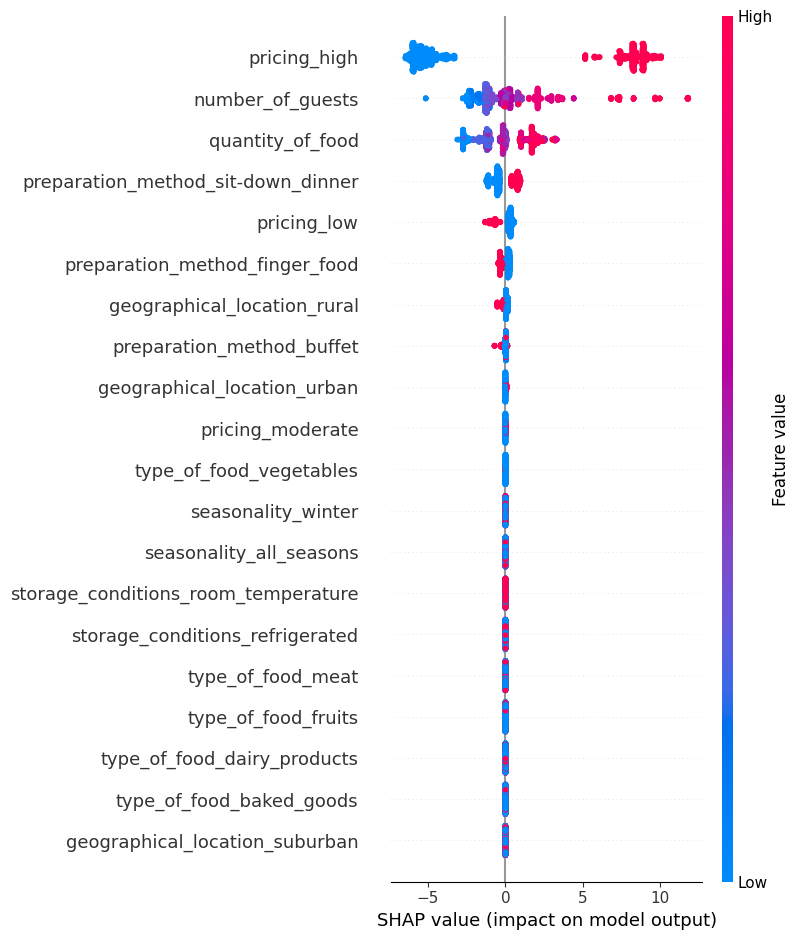

In [39]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

# Plot the SHAP values
shap.summary_plot(shap_values, X_train, plot_type="dot")
plt.show()

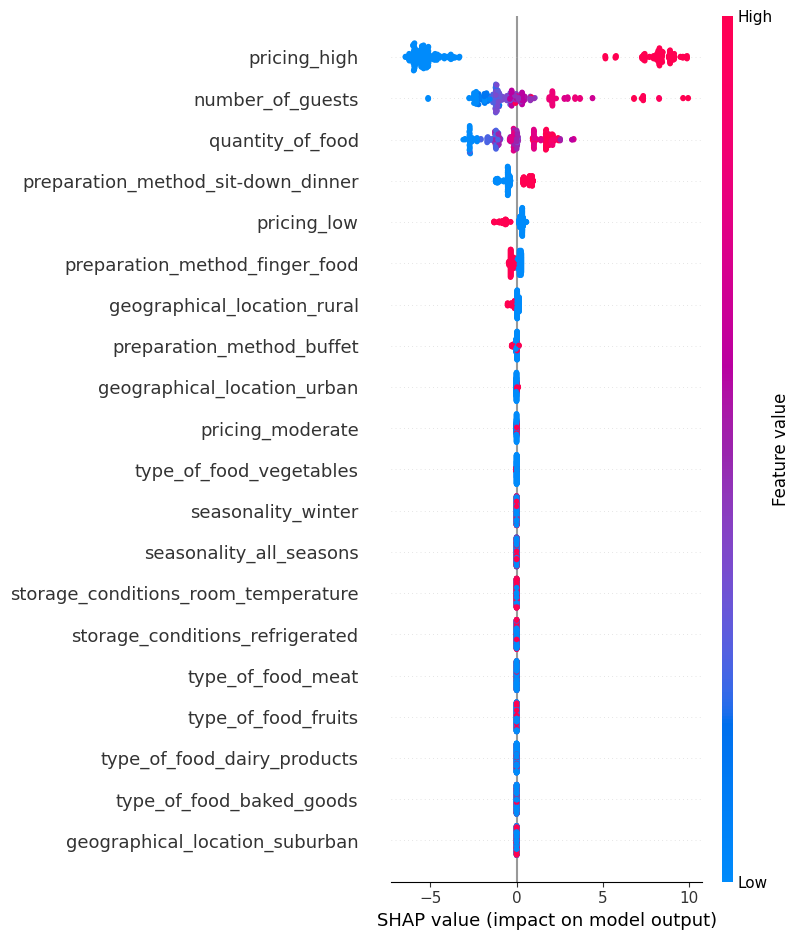

In [40]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot the SHAP values
shap.summary_plot(shap_values, X_test, plot_type="dot")
plt.show()

In [41]:
# SAVE MODEL
# Save the model
model.save_model("xgboost_model_v2.json")

In [34]:
booster = xgb.Booster()
booster.load_model("xgboost_model_v1.json")

## Prediction

In [62]:
import pandas as pd
import json
import xgboost as xgb

# Load the XGBoost model
booster = xgb.Booster()
booster.load_model("xgboost_model_v1.json")

# Define the JSON data
json_data = {
    "number_of_guests": 40,
    "quantity_of_food": 200,
    "type_of_food_baked_goods": 1,
    "type_of_food_dairy_products": 0,
    "type_of_food_fruits": 0,
    "type_of_food_meat": 0,
    "type_of_food_vegetables": 0,
    "event_type_birthday": 0,
    "event_type_corporate": 1,
    "event_type_social_gathering": 0,
    "event_type_wedding": 0,
    "storage_conditions_refrigerated": 0,
    "storage_conditions_room_temperature": 1,
    "seasonality_all_seasons": 1,
    "seasonality_summer": 0,
    "seasonality_winter": 0,
    "preparation_method_buffet": 1,
    "preparation_method_finger_food": 0,
    "preparation_method_sit-down_dinner": 0,
    "geographical_location_rural": 0,
    "geographical_location_suburban": 1,
    "geographical_location_urban": 0,
    "pricing_high": 0,
    "pricing_low": 0,
    "pricing_moderate": 1
}

# Convert the JSON keys into column names
column_names = list(json_data.keys())

# Create a DataFrame with the JSON data and updated column names
df = pd.DataFrame([json_data], columns=column_names)

# Use the XGBoost model to make predictions
predictions = booster.predict(xgb.DMatrix(df))

# Print the predictions
print(predictions[0])

18.018175


In [33]:
xgb.__version__

'2.0.3'

In [1]:
!python --version

Python 3.10.13


# CATBOOST

In [37]:
!pip install catboost

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


In [48]:
from catboost import CatBoostRegressor
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [40]:
df_enc_copy = df_enc[required_columns].copy(deep = True)
y = df_enc_copy['wastage_food_amount']
df_enc_copy.drop(columns = ['wastage_food_amount'], inplace = True)
X = df_enc_copy

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
# Define parameters for CatBoost model
params = {
    'iterations': 100,
    'learning_rate': 0.1,
    'depth': 2,
}

# Initialize CatBoost regressor with specified parameters
model = CatBoostRegressor(**params)

# Train the model
model.fit(X_train, y_train)

0:	learn: 9.7973564	total: 545us	remaining: 54ms
1:	learn: 9.1740998	total: 1.48ms	remaining: 72.4ms
2:	learn: 8.6612206	total: 1.92ms	remaining: 62.1ms
3:	learn: 8.1801874	total: 2.49ms	remaining: 59.8ms
4:	learn: 7.7652305	total: 2.9ms	remaining: 55.1ms
5:	learn: 7.3869471	total: 3.32ms	remaining: 52ms
6:	learn: 7.0657176	total: 3.77ms	remaining: 50.1ms
7:	learn: 6.7963956	total: 4.2ms	remaining: 48.3ms
8:	learn: 6.5662585	total: 4.75ms	remaining: 48.1ms
9:	learn: 6.3726261	total: 5.15ms	remaining: 46.4ms
10:	learn: 6.2026427	total: 5.5ms	remaining: 44.5ms
11:	learn: 6.0607270	total: 5.83ms	remaining: 42.8ms
12:	learn: 5.9391815	total: 6.27ms	remaining: 42ms
13:	learn: 5.8366941	total: 6.73ms	remaining: 41.4ms
14:	learn: 5.7345269	total: 7.13ms	remaining: 40.4ms
15:	learn: 5.6549373	total: 7.48ms	remaining: 39.3ms
16:	learn: 5.5791487	total: 7.84ms	remaining: 38.3ms
17:	learn: 5.5049231	total: 8.27ms	remaining: 37.7ms
18:	learn: 5.4641558	total: 8.65ms	remaining: 36.9ms
19:	learn: 5.

In [50]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R^2):", r2)

Mean Absolute Error (MAE): 3.3587557280291076
Mean Squared Error (MSE): 18.16119775572343
Root Mean Squared Error (RMSE): 4.261595681868873
R-squared (R^2): 0.8247965993421891


In [51]:
X_train.columns

Index(['number_of_guests', 'quantity_of_food', 'type_of_food_baked_goods',
       'type_of_food_dairy_products', 'type_of_food_fruits',
       'type_of_food_meat', 'type_of_food_vegetables', 'event_type_birthday',
       'event_type_corporate', 'event_type_social_gathering',
       'event_type_wedding', 'storage_conditions_refrigerated',
       'storage_conditions_room_temperature', 'seasonality_all_seasons',
       'seasonality_summer', 'seasonality_winter', 'preparation_method_buffet',
       'preparation_method_finger_food', 'preparation_method_sit-down_dinner',
       'geographical_location_rural', 'geographical_location_suburban',
       'geographical_location_urban', 'pricing_high', 'pricing_low',
       'pricing_moderate'],
      dtype='object')

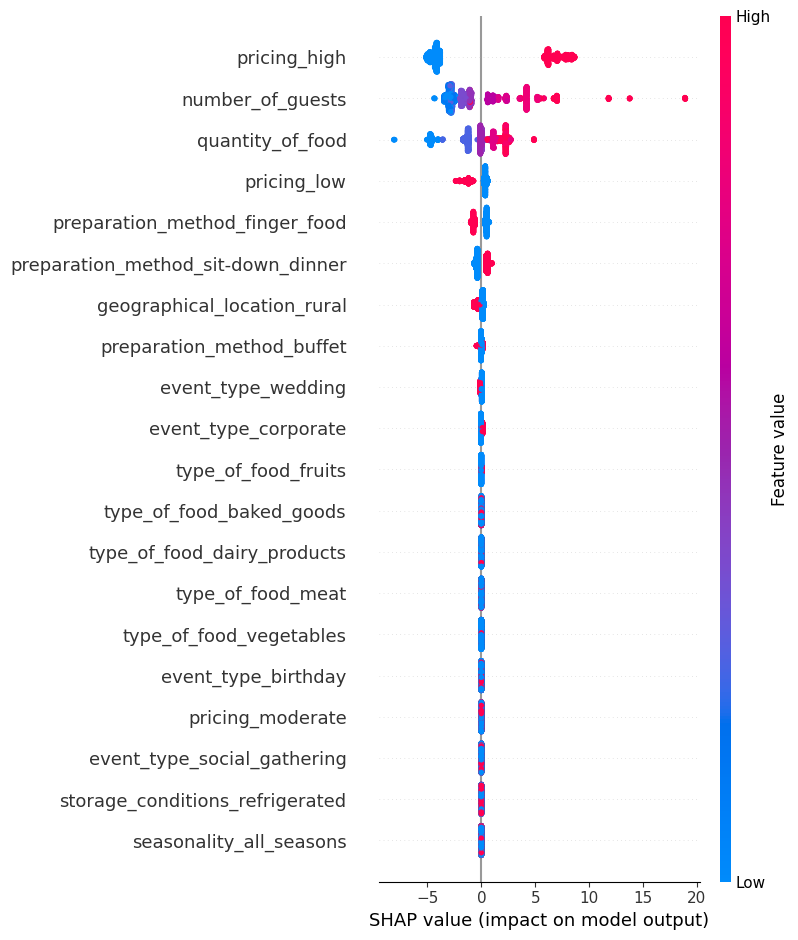

In [52]:
# Explain the model's predictions using SHAP values
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(X_train)

# Visualize the SHAP values
shap.summary_plot(shap_values, X_train, feature_names=X_train.columns, plot_type="dot")

# PLOTS

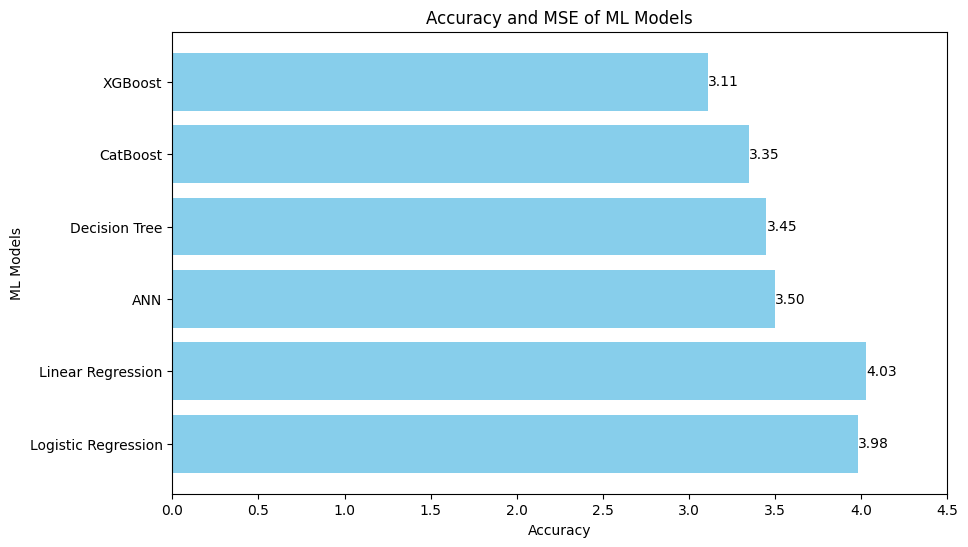

In [2]:
import matplotlib.pyplot as plt

# Sample data (replace with your own)
models = ['XGBoost', 'CatBoost', 'Decision Tree','ANN','Linear Regression', 'Logistic Regression']
mses = [3.11, 3.35, 3.45, 3.5, 4.03, 3.98]  # Accuracy scores corresponding to each model

# Create horizontal bar chart
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
bars = plt.barh(models, mses, color='skyblue')

# Annotate each bar with its corresponding MSE value
for bar, mse in zip(bars, mses):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{mse:.2f}', 
             va='center', ha='left', fontsize=10, color='black')

plt.xlabel('Accuracy')
plt.ylabel('ML Models')
plt.title('Accuracy and MSE of ML Models')
plt.xlim(0, 4.5)  # Set X-axis limits from 0 to 1 (assuming accuracy scores are between 0 and 1)
# plt.grid(axis='x')  # Add grid lines only on X-axis for better readability
plt.gca().invert_yaxis()  # Invert Y-axis to display models from top to bottom
plt.savefig('bar_chart.png', bbox_inches='tight', dpi=300)  # Adjust file name and dpi as needed
plt.show()

In [21]:
plt.savefig('bar_chart.png', bbox_inches='tight', dpi=300)  # Adjust file name and dpi as needed

<Figure size 640x480 with 0 Axes>

# ANNs

In [54]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),  # Add dropout layer with 20% dropout rate
    Dense(32, activation='relu'),
    Dropout(0.2),  # Add dropout layer with 20% dropout rate
    Dense(1)  # Output layer
])

# Compile the model
model_ann.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model_ann.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
test_loss = model_ann.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 28112.1875 - val_loss: 458.9110
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1525.6006 - val_loss: 121.7332
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 793.7648 - val_loss: 60.4237
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 474.0624 - val_loss: 97.1309
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 342.4599 - val_loss: 95.6217
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 265.2583 - val_loss: 90.6673
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 216.8355 - val_loss: 89.7788
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 230.3453 - val_loss: 86.5989
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 187.8272 - val_loss: 78.9925
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 175.7992 - val_loss: 73.3299
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 178.5315 - val_loss: 87.6196
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━

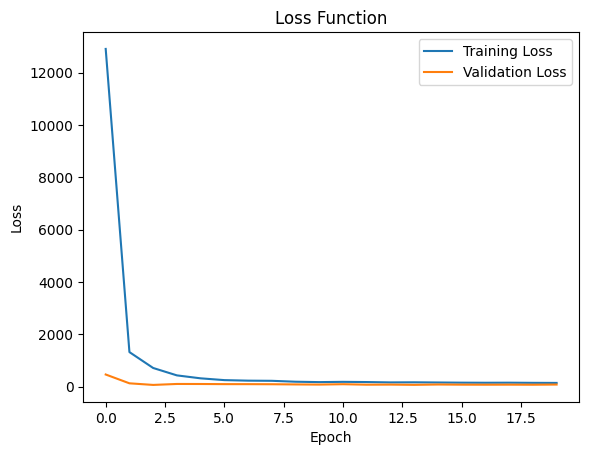

In [55]:
# Plot the loss function
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Function')
plt.legend()
plt.show()

In [56]:
# Save the model
model_ann.save("ann_model_v1.h5")
# Load the model
# loaded_model = tf.keras.models.load_model("my_model.h5")

## Predictions

In [58]:
from tensorflow.keras.models import load_model

# Load the saved ANN model
model_ann_loaded = load_model("ann_model_v1.h5")

In [61]:
# Use the ANN model to make predictions
predictions = model_ann_loaded.predict(df)

# Print the predictions
print(predictions[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
8.480832


# APPENDIX

In [ ]:
pip freeze